In [ ]:
from google.colab import files
uploaded = files.upload()

Saving silver_with_indicators.csv to silver_with_indicators (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('silver_with_indicators.csv')
print(df.head())
print(df.columns.tolist())

         Date    Open    High     Low   Close  Adj_Close  Volume    VWAP  \
0  2000-01-03  5.1962  5.1962  5.1884  5.1910     5.1910   36286  5.1919   
1  2000-01-04  5.1084  5.1084  5.0848  5.0980     5.0980   35819  5.0971   
2  2000-01-05  5.1388  5.1464  5.1388  5.1412     5.1412   38844  5.1421   
3  2000-01-06  5.2123  5.2291  5.2123  5.2239     5.2239   24445  5.2218   
4  2000-01-07  5.2766  5.2832  5.2766  5.2779     5.2779   40020  5.2792   

   Returns_Pct  Log_Returns  ...  BB_Mid  BB_Upper  BB_Lower  Volatility_20  \
0      -0.1729    -0.001731  ...     NaN       NaN       NaN            NaN   
1      -1.7916    -0.018079  ...     NaN       NaN       NaN            NaN   
2       0.8480     0.008444  ...     NaN       NaN       NaN            NaN   
3       1.6076     0.015948  ...     NaN       NaN       NaN            NaN   
4       1.0344     0.010291  ...     NaN       NaN       NaN            NaN   

   Momentum_10  Price_Rate_of_Change  High_Low_Pct  Close_SMA20_Dist

In [ ]:
!pip install xgboost shap -q

Using features: ['Volume', 'VWAP', 'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range', 'Intraday_Range_Pct', 'Daily_Return']... total 29

✅ XGBoost RMSE: 0.1765


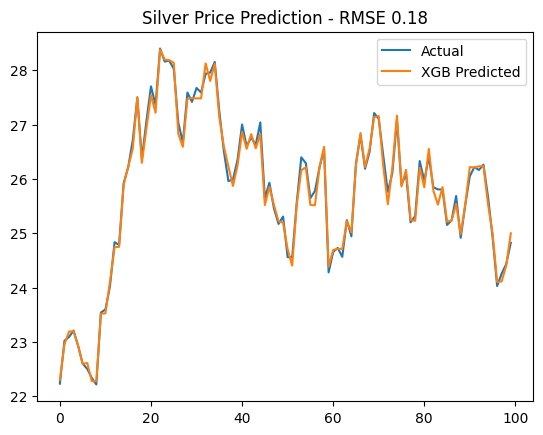

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Clean NaNs (first 20 rows have NaN because of indicators)
df_clean = df.dropna()

# Auto-select best features - we take numeric columns except targets
exclude = ['Date','Close','Adj_Close','Open','High','Low']
features = [c for c in df_clean.columns if c not in exclude and df_clean[c].dtype!= 'object']
X = df_clean[features]
y = df_clean['Close']

print(f"Using features: {features[:8]}... total {len(features)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = xgb.XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.05)
model.fit(X_train, y_train)

pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"\n✅ XGBoost RMSE: {rmse:.4f}")

# For PPT
import matplotlib.pyplot as plt
plt.figure()
plt.plot(y_test.values[:100], label='Actual')
plt.plot(pred[:100], label='XGB Predicted')
plt.legend()
plt.title(f'Silver Price Prediction - RMSE {rmse:.2f}')
plt.show()

Generating SHAP plot...


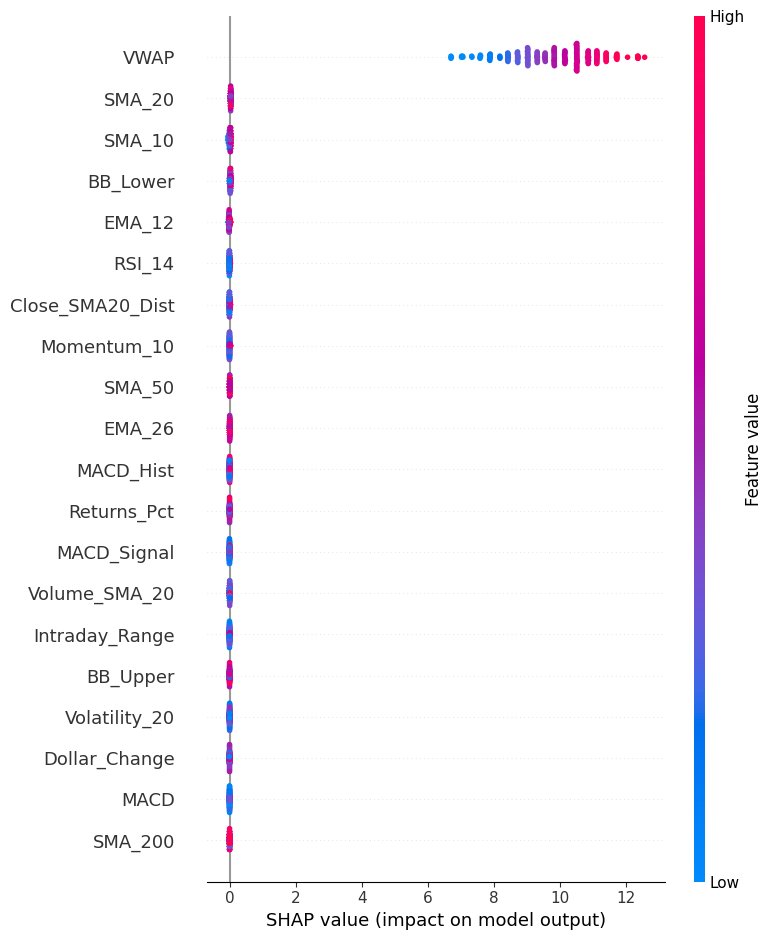

✅ SHAP plot saved as shap_plot.png - Download it from left folder panel


In [ ]:
import shap

# SHAP needs smaller data for mobile
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:200])

print("Generating SHAP plot...")
shap.summary_plot(shap_values, X_test[:200], show=False)
plt.savefig('shap_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP plot saved as shap_plot.png - Download it from left folder panel")

In [ ]:
from google.colab import files
print("Upload Day_7_LSTM_Predictions.csv")
up = files.upload()

Upload Day_7_LSTM_Predictions.csv


Saving Day_7_LSTM_Predictions.csv to Day_7_LSTM_Predictions (1).csv


XGBoost RMSE: 0.1765
Ensemble RMSE: 1.0461


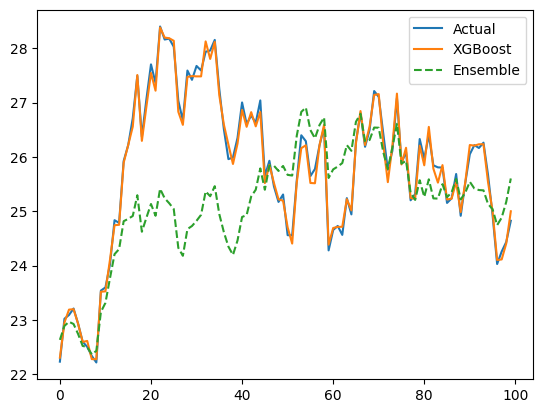

✅ Saved - Ready for GitHub


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

lstm_df = pd.read_csv('Day_7_LSTM_Predictions.csv')
lstm_pred = lstm_df['Predicted'].values if 'Predicted' in lstm_df.columns else lstm_df.iloc[:,1].values

min_len = min(len(pred), len(lstm_pred), len(y_test))
y_true = y_test.values[:min_len]
xgb = pred[:min_len]
lstm = lstm_pred[:min_len]

ensemble = (xgb + lstm) / 2

print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_true, xgb)):.4f}")
print(f"Ensemble RMSE: {np.sqrt(mean_squared_error(y_true, ensemble)):.4f}")

plt.plot(y_true[:100], label='Actual')
plt.plot(xgb[:100], label='XGBoost')
plt.plot(ensemble[:100], label='Ensemble', linestyle='--')
plt.legend()
plt.savefig('Day_9_Ensemble_Forecast.png')
plt.show()

pd.DataFrame({'Actual':y_true,'XGBoost':xgb,'Ensemble':ensemble}).to_csv('Day_9_Ensemble_Predictions.csv', index=False)
print("✅ Saved - Ready for GitHub")